## 🧠 DQN for Inventory Management (Basic Version)

This code implements a Deep Q-Network (DQN) to learn optimal ordering decisions in an inventory system with stochastic demand.  
The agent learns to maximize profit by balancing ordering cost, holding cost, and stockout penalties.  
It uses experience replay and a target network for stable training.

Episode 50/300 | Profit 279.00
Episode 100/300 | Profit 266.44
Episode 150/300 | Profit 277.06
Episode 200/300 | Profit 278.06
Episode 250/300 | Profit 312.74
Episode 300/300 | Profit 262.41


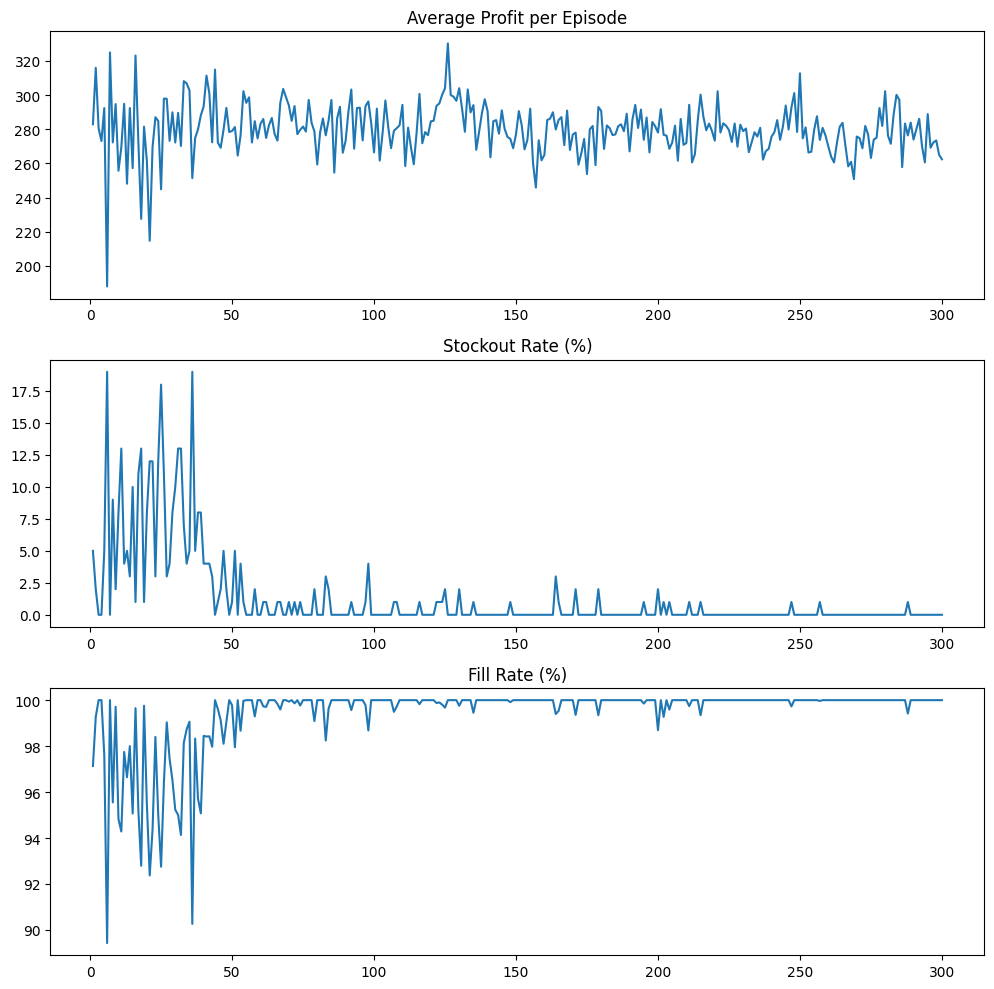

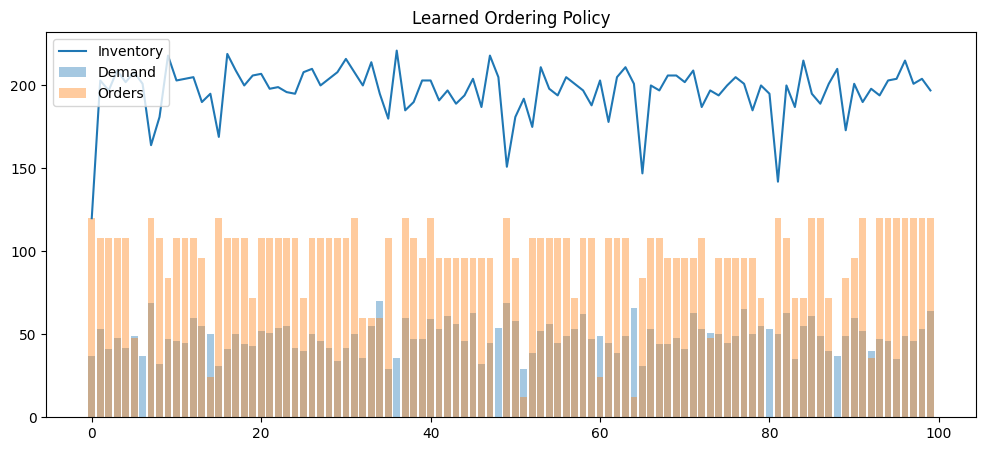

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt


# =========================================================
# CONFIGURATION
# =========================================================

CONFIG = {

    # Inventory system
    "max_order": 120,
    "max_inventory": 250,
    "initial_inventory": 120,

    # Pack constraint
    "pack_size": 12,

    # Costs
    "selling_price": 20,
    "ordering_cost": 12,
    "holding_cost": 0.8,
    "stockout_penalty": 15,

    # Demand distribution
    "demand_mean": 50,
    "demand_std": 10,

    # Forecast noise
    "forecast_noise_std": 5,

    # RL parameters
    "episodes": 300,
    "days_per_episode": 100,
    "batch_size": 64,
    "gamma": 0.99,
    "learning_rate": 5e-4,

    # Exploration
    "epsilon_start": 1.0,
    "epsilon_decay": 0.995,
    "epsilon_min": 0.05,

    # Neural network
    "hidden_units": 64
}


# =========================================================
# ACTION SPACE
# =========================================================

def create_action_space(config):
    pack = config["pack_size"]
    max_order = config["max_order"]
    return list(range(0, max_order + 1, pack))


# =========================================================
# INVENTORY ENVIRONMENT
# =========================================================

class InventoryEnv:

    def __init__(self, config):

        self.config = config

        self.max_order = config["max_order"]
        self.max_inventory = config["max_inventory"]

        self.price = config["selling_price"]
        self.order_cost = config["ordering_cost"]
        self.holding_cost = config["holding_cost"]
        self.stockout_penalty = config["stockout_penalty"]

        self.reset()

    def reset(self):

        self.inventory = self.config["initial_inventory"]
        self.pipeline = 0

        _, forecast = self.sample_demand()

        return np.array([self.inventory, self.pipeline, forecast], dtype=np.float32)

    def sample_demand(self):

        mean = self.config["demand_mean"]
        std = self.config["demand_std"]

        demand = int(np.random.normal(mean, std))
        demand = max(0, demand)

        noise_std = self.config["forecast_noise_std"]
        noise = np.random.normal(0, noise_std)

        forecast = max(0, demand + noise)

        return demand, forecast

    def step(self, order):

        order = max(0, min(order, self.max_order))
        available_space = max(0, self.max_inventory - (self.inventory + self.pipeline))
        order = min(order, available_space)

        demand, _ = self.sample_demand()

        inventory_available = self.inventory + self.pipeline

        sales = min(inventory_available, demand)
        lost_sales = max(0, demand - inventory_available)

        next_inventory = inventory_available - sales
        next_pipeline = order

        revenue = self.price * sales
        ordering_cost = self.order_cost * order
        holding_cost = self.holding_cost * next_inventory
        stockout_cost = self.stockout_penalty * lost_sales

        reward = revenue - ordering_cost - holding_cost - stockout_cost

        self.inventory = next_inventory
        self.pipeline = next_pipeline

        _, next_forecast = self.sample_demand()

        next_state = np.array(
            [self.inventory, self.pipeline, next_forecast],
            dtype=np.float32
        )

        stockout = 1 if lost_sales > 0 else 0
        fill_rate = sales / demand if demand > 0 else 1

        return next_state, reward, demand, inventory_available, stockout, fill_rate


# =========================================================
# Q NETWORK
# =========================================================

class QNetwork(nn.Module):

    def __init__(self, state_dim, action_dim, hidden_units):

        super(QNetwork, self).__init__()

        self.fc1 = nn.Linear(state_dim, hidden_units)
        self.fc2 = nn.Linear(hidden_units, hidden_units)
        self.fc3 = nn.Linear(hidden_units, action_dim)

    def forward(self, x):

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))

        return self.fc3(x)


# =========================================================
# DQN AGENT
# =========================================================

class DQNAgent:

    def __init__(self, state_dim, action_dim, config):

        self.gamma = config["gamma"]

        self.epsilon = config["epsilon_start"]
        self.epsilon_decay = config["epsilon_decay"]
        self.epsilon_min = config["epsilon_min"]

        hidden = config["hidden_units"]

        self.q_network = QNetwork(state_dim, action_dim, hidden)
        self.target_network = QNetwork(state_dim, action_dim, hidden)

        self.target_network.load_state_dict(self.q_network.state_dict())

        self.optimizer = optim.Adam(
            self.q_network.parameters(),
            lr=config["learning_rate"]
        )

        self.loss_fn = nn.SmoothL1Loss()

        self.replay_buffer = deque(maxlen=50000)

        self.batch_size = config["batch_size"]
        self.action_dim = action_dim

    def select_action(self, state):

        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_dim)

        state_tensor = torch.FloatTensor(state).unsqueeze(0)

        with torch.no_grad():
            q_values = self.q_network(state_tensor)

        return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state):

        self.replay_buffer.append((state, action, reward, next_state))

    def train(self):

        if len(self.replay_buffer) < self.batch_size:
            return

        batch = random.sample(self.replay_buffer, self.batch_size)

        states, actions, rewards, next_states = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states))

        current_q = self.q_network(states).gather(1, actions)

        with torch.no_grad():
            next_q = self.target_network(next_states).max(1)[0].unsqueeze(1)
            target_q = rewards + self.gamma * next_q

        loss = self.loss_fn(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target_network(self):

        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# =========================================================
# VISUALIZATION
# =========================================================

def plot_training_metrics(episodes, profits, stockouts, fill_rates):

    fig, axs = plt.subplots(3, 1, figsize=(10, 10))

    axs[0].plot(episodes, profits)
    axs[0].set_title("Average Profit per Episode")

    axs[1].plot(episodes, stockouts)
    axs[1].set_title("Stockout Rate (%)")

    axs[2].plot(episodes, fill_rates)
    axs[2].set_title("Fill Rate (%)")

    plt.tight_layout()
    plt.show()


def plot_policy(days, inventory, orders, demand):

    plt.figure(figsize=(12, 5))

    plt.plot(days, inventory, label="Inventory")
    plt.bar(days, demand, alpha=0.4, label="Demand")
    plt.bar(days, orders, alpha=0.4, label="Orders")

    plt.legend()
    plt.title("Learned Ordering Policy")

    plt.show()


# =========================================================
# TRAINING LOOP
# =========================================================

def train():

    env = InventoryEnv(CONFIG)

    actions = create_action_space(CONFIG)

    agent = DQNAgent(
        state_dim=3,
        action_dim=len(actions),
        config=CONFIG
    )

    profits = []
    stockouts = []
    fill_rates = []

    for episode in range(CONFIG["episodes"]):

        state = env.reset()

        total_reward = 0
        total_stockout = 0
        total_fill = 0

        days = []
        inventory_history = []
        order_history = []
        demand_history = []

        for day in range(CONFIG["days_per_episode"]):

            action_idx = agent.select_action(state)
            action = actions[action_idx]

            next_state, reward, demand, inventory_avail, stockout, fill = env.step(action)

            agent.store_transition(state, action_idx, reward, next_state)

            agent.train()

            state = next_state

            total_reward += reward
            total_stockout += stockout
            total_fill += fill

            if episode == CONFIG["episodes"] - 1:

                days.append(day)
                inventory_history.append(inventory_avail)
                order_history.append(action)
                demand_history.append(demand)

        if episode % 10 == 0:
            agent.update_target_network()

        agent.decay_epsilon()

        profits.append(total_reward / CONFIG["days_per_episode"])
        stockouts.append((total_stockout / CONFIG["days_per_episode"]) * 100)
        fill_rates.append((total_fill / CONFIG["days_per_episode"]) * 100)

        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1}/{CONFIG['episodes']} | Profit {profits[-1]:.2f}")

    episodes = range(1, CONFIG["episodes"] + 1)

    plot_training_metrics(episodes, profits, stockouts, fill_rates)

    plot_policy(days, inventory_history, order_history, demand_history)


# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":
    train()

## 📊 DQN with Evaluation (Deterministic Results)

This version adds reproducibility using random seeds and includes a final evaluation phase without exploration.  
After training, the agent is tested to measure true performance (profit, stockouts, fill rate).  
This helps verify how well the learned policy performs in a stable setting.

Episode 50/300 | Profit 256.12
Episode 100/300 | Profit 277.72
Episode 150/300 | Profit 279.35
Episode 200/300 | Profit 256.26
Episode 250/300 | Profit 298.37
Episode 300/300 | Profit 279.14


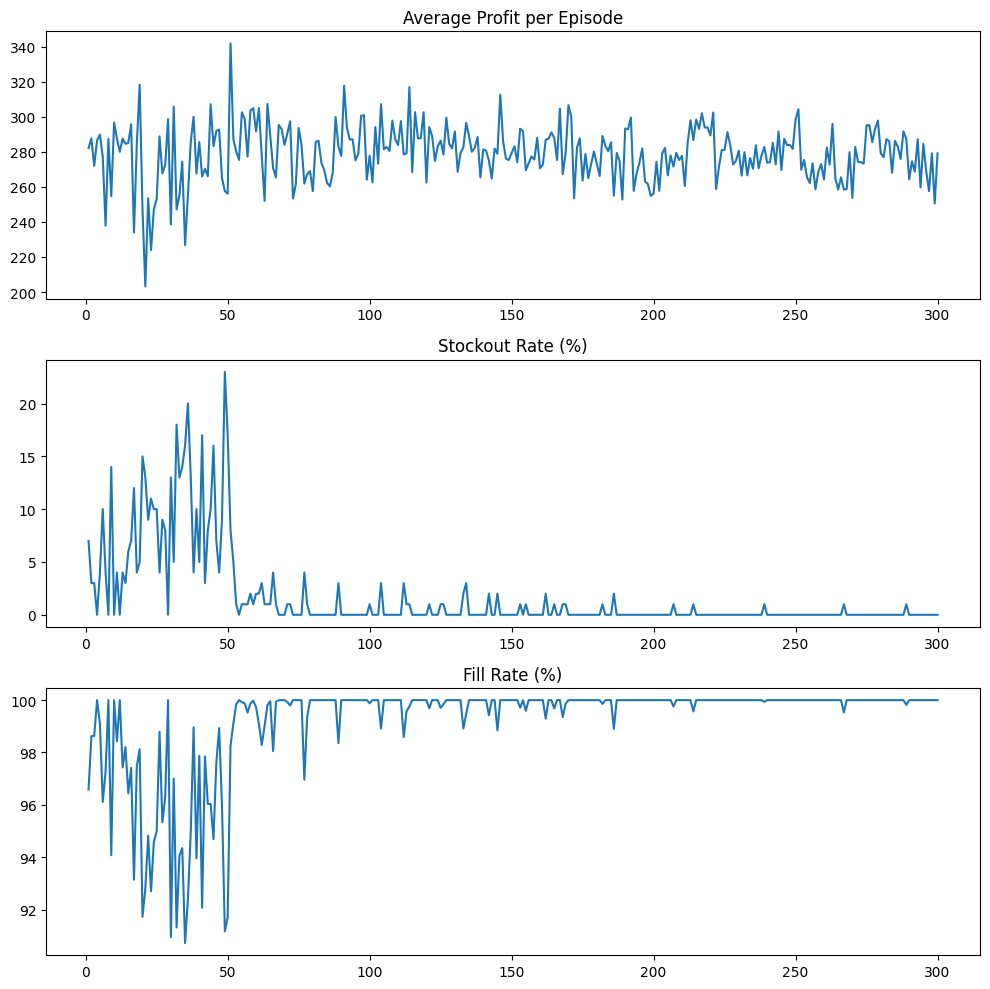

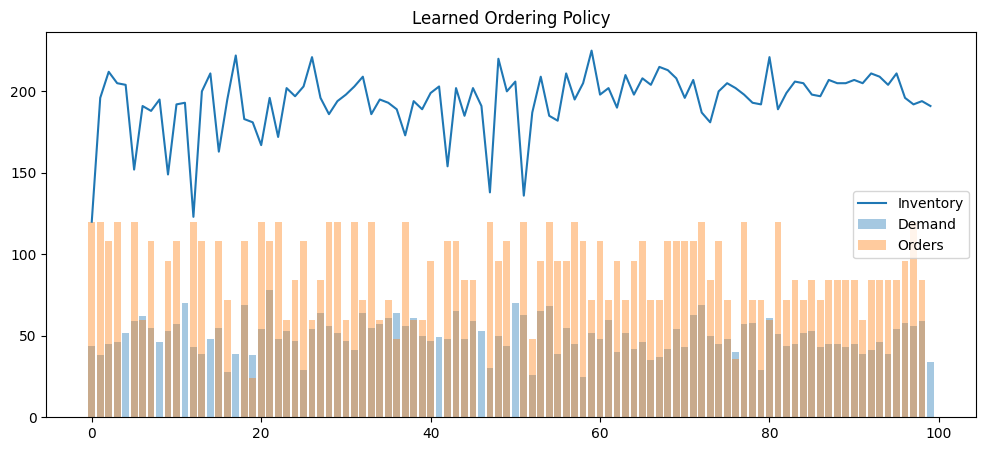


========== FINAL EVALUATION (NO EXPLORATION) ==========
Average Profit: 270.18
Stockout Rate: 0.00%
Fill Rate: 100.00%



In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt


# =========================================================
# CONFIGURATION
# =========================================================

CONFIG = {

    # Inventory system
    "max_order": 120,
    "max_inventory": 250,
    "initial_inventory": 120,

    # Pack constraint
    "pack_size": 12,

    # Costs
    "selling_price": 20,
    "ordering_cost": 12,
    "holding_cost": 0.8,
    "stockout_penalty": 15,

    # Demand distribution
    "demand_mean": 50,
    "demand_std": 10,

    # Forecast noise
    "forecast_noise_std": 5,

    # RL parameters
    "episodes": 300,
    "days_per_episode": 100,
    "batch_size": 64,
    "gamma": 0.99,
    "learning_rate": 5e-4,

    # Exploration
    "epsilon_start": 1.0,
    "epsilon_decay": 0.995,
    "epsilon_min": 0.05,

    # Neural network
    "hidden_units": 64
}

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)


# =========================================================
# ACTION SPACE
# =========================================================

def create_action_space(config):
    pack = config["pack_size"]
    max_order = config["max_order"]
    return list(range(0, max_order + 1, pack))

# =========================================================
# FINAL NUMERICAL RESULTS
# =========================================================

def evaluate_agent(env, agent, actions, episodes=10):

    agent.epsilon = 0  # no exploration (important)

    total_profit = 0
    total_stockout = 0
    total_fill = 0

    for _ in range(episodes):

        state = env.reset()

        for _ in range(CONFIG["days_per_episode"]):

            action_idx = agent.select_action(state)
            action = actions[action_idx]

            next_state, reward, demand, inventory_avail, stockout, fill = env.step(action)

            state = next_state

            total_profit += reward
            total_stockout += stockout
            total_fill += fill

    avg_profit = total_profit / (episodes * CONFIG["days_per_episode"])
    stockout_rate = (total_stockout / (episodes * CONFIG["days_per_episode"])) * 100
    fill_rate = (total_fill / (episodes * CONFIG["days_per_episode"])) * 100

    print("\n========== FINAL EVALUATION (NO EXPLORATION) ==========")
    print(f"Average Profit: {avg_profit:.2f}")
    print(f"Stockout Rate: {stockout_rate:.2f}%")
    print(f"Fill Rate: {fill_rate:.2f}%")
    print("======================================================\n")




# =========================================================
# INVENTORY ENVIRONMENT
# =========================================================

class InventoryEnv:

    def __init__(self, config):

        self.config = config

        self.max_order = config["max_order"]
        self.max_inventory = config["max_inventory"]

        self.price = config["selling_price"]
        self.order_cost = config["ordering_cost"]
        self.holding_cost = config["holding_cost"]
        self.stockout_penalty = config["stockout_penalty"]

        self.reset()

    def reset(self):

        self.inventory = self.config["initial_inventory"]
        self.pipeline = 0

        _, forecast = self.sample_demand()

        return np.array([self.inventory, self.pipeline, forecast], dtype=np.float32)

    def sample_demand(self):

        mean = self.config["demand_mean"]
        std = self.config["demand_std"]

        demand = int(np.random.normal(mean, std))
        demand = max(0, demand)

        noise_std = self.config["forecast_noise_std"]
        noise = np.random.normal(0, noise_std)

        forecast = max(0, demand + noise)

        return demand, forecast

    def step(self, order):

        order = max(0, min(order, self.max_order))
        available_space = max(0, self.max_inventory - (self.inventory + self.pipeline))
        order = min(order, available_space)

        demand, _ = self.sample_demand()

        inventory_available = self.inventory + self.pipeline

        sales = min(inventory_available, demand)
        lost_sales = max(0, demand - inventory_available)

        next_inventory = inventory_available - sales
        next_pipeline = order

        revenue = self.price * sales
        ordering_cost = self.order_cost * order
        holding_cost = self.holding_cost * next_inventory
        stockout_cost = self.stockout_penalty * lost_sales

        reward = revenue - ordering_cost - holding_cost - stockout_cost

        self.inventory = next_inventory
        self.pipeline = next_pipeline

        _, next_forecast = self.sample_demand()

        next_state = np.array(
            [self.inventory, self.pipeline, next_forecast],
            dtype=np.float32
        )

        stockout = 1 if lost_sales > 0 else 0
        fill_rate = sales / demand if demand > 0 else 1

        return next_state, reward, demand, inventory_available, stockout, fill_rate


# =========================================================
# Q NETWORK
# =========================================================

class QNetwork(nn.Module):

    def __init__(self, state_dim, action_dim, hidden_units):

        super(QNetwork, self).__init__()

        self.fc1 = nn.Linear(state_dim, hidden_units)
        self.fc2 = nn.Linear(hidden_units, hidden_units)
        self.fc3 = nn.Linear(hidden_units, action_dim)

    def forward(self, x):

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))

        return self.fc3(x)


# =========================================================
# DQN AGENT
# =========================================================

class DQNAgent:

    def __init__(self, state_dim, action_dim, config):

        self.gamma = config["gamma"]

        self.epsilon = config["epsilon_start"]
        self.epsilon_decay = config["epsilon_decay"]
        self.epsilon_min = config["epsilon_min"]

        hidden = config["hidden_units"]

        self.q_network = QNetwork(state_dim, action_dim, hidden)
        self.target_network = QNetwork(state_dim, action_dim, hidden)

        self.target_network.load_state_dict(self.q_network.state_dict())

        self.optimizer = optim.Adam(
            self.q_network.parameters(),
            lr=config["learning_rate"]
        )

        self.loss_fn = nn.SmoothL1Loss()

        self.replay_buffer = deque(maxlen=50000)

        self.batch_size = config["batch_size"]
        self.action_dim = action_dim

    def select_action(self, state):

        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_dim)

        state_tensor = torch.FloatTensor(state).unsqueeze(0)

        with torch.no_grad():
            q_values = self.q_network(state_tensor)

        return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state):

        self.replay_buffer.append((state, action, reward, next_state))

    def train(self):

        if len(self.replay_buffer) < self.batch_size:
            return

        batch = random.sample(self.replay_buffer, self.batch_size)

        states, actions, rewards, next_states = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states))

        current_q = self.q_network(states).gather(1, actions)

        with torch.no_grad():
            next_q = self.target_network(next_states).max(1)[0].unsqueeze(1)
            target_q = rewards + self.gamma * next_q

        loss = self.loss_fn(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


    def update_target_network(self):

        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# =========================================================
# VISUALIZATION
# =========================================================

def plot_training_metrics(episodes, profits, stockouts, fill_rates):

    fig, axs = plt.subplots(3, 1, figsize=(10, 10))

    axs[0].plot(episodes, profits)
    axs[0].set_title("Average Profit per Episode")

    axs[1].plot(episodes, stockouts)
    axs[1].set_title("Stockout Rate (%)")

    axs[2].plot(episodes, fill_rates)
    axs[2].set_title("Fill Rate (%)")

    plt.tight_layout()
    plt.show()


def plot_policy(days, inventory, orders, demand):

    plt.figure(figsize=(12, 5))

    plt.plot(days, inventory, label="Inventory")
    plt.bar(days, demand, alpha=0.4, label="Demand")
    plt.bar(days, orders, alpha=0.4, label="Orders")

    plt.legend()
    plt.title("Learned Ordering Policy")

    plt.show()


# =========================================================
# TRAINING LOOP
# =========================================================

def train():

    env = InventoryEnv(CONFIG)

    actions = create_action_space(CONFIG)

    agent = DQNAgent(
        state_dim=3,
        action_dim=len(actions),
        config=CONFIG
    )

    profits = []
    stockouts = []
    fill_rates = []

    for episode in range(CONFIG["episodes"]):

        state = env.reset()

        total_reward = 0
        total_stockout = 0
        total_fill = 0

        days = []
        inventory_history = []
        order_history = []
        demand_history = []

        for day in range(CONFIG["days_per_episode"]):

            action_idx = agent.select_action(state)
            action = actions[action_idx]

            next_state, reward, demand, inventory_avail, stockout, fill = env.step(action)

            agent.store_transition(state, action_idx, reward, next_state)

            agent.train()

            state = next_state

            total_reward += reward
            total_stockout += stockout
            total_fill += fill

            if episode == CONFIG["episodes"] - 1:

                days.append(day)
                inventory_history.append(inventory_avail)
                order_history.append(action)
                demand_history.append(demand)

        if episode % 10 == 0:
            agent.update_target_network()

        agent.decay_epsilon()

        profits.append(total_reward / CONFIG["days_per_episode"])
        stockouts.append((total_stockout / CONFIG["days_per_episode"]) * 100)
        fill_rates.append((total_fill / CONFIG["days_per_episode"]) * 100)

        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1}/{CONFIG['episodes']} | Profit {profits[-1]:.2f}")

    episodes = range(1, CONFIG["episodes"] + 1)

    plot_training_metrics(episodes, profits, stockouts, fill_rates)

    plot_policy(days, inventory_history, order_history, demand_history)
    evaluate_agent(env, agent, actions)


# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":
    train()

#code1

## 📈 DQN with Poisson Demand

This version improves realism by modeling demand using a Poisson distribution instead of a normal distribution.  
Poisson demand better represents real-world scenarios like customer arrivals.  
The rest of the DQN pipeline remains the same for fair comparison.

Episode 50/300 | Profit 313.16
Episode 100/300 | Profit 299.67
Episode 150/300 | Profit 290.02
Episode 200/300 | Profit 269.95
Episode 250/300 | Profit 288.77
Episode 300/300 | Profit 270.31


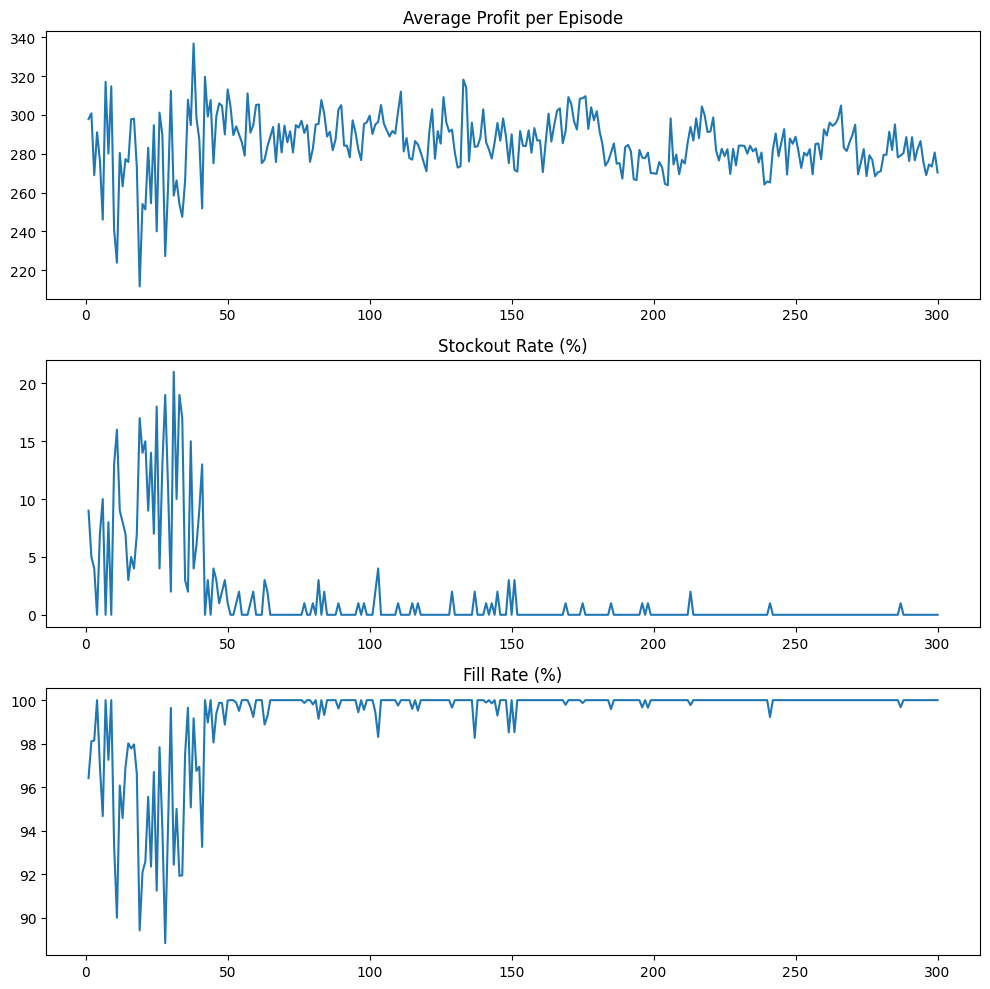

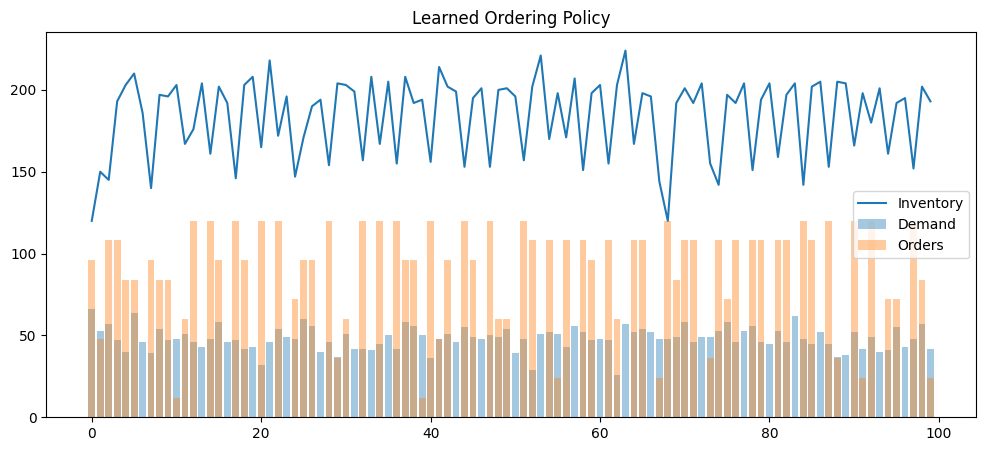


========== FINAL EVALUATION (NO EXPLORATION) ==========
Average Profit: 283.04
Stockout Rate: 0.00%
Fill Rate: 100.00%



In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt


# =========================================================
# CONFIGURATION
# =========================================================

CONFIG = {

    # Inventory system
    "max_order": 120,
    "max_inventory": 250,
    "initial_inventory": 120,

    # Pack constraint
    "pack_size": 12,

    # Costs
    "selling_price": 20,
    "ordering_cost": 12,
    "holding_cost": 0.8,
    "stockout_penalty": 15,

    # Demand distribution
    "demand_mean": 50,
    "demand_std": 10,

    # Forecast noise
    "forecast_noise_std": 5,

    # RL parameters
    "episodes": 300,
    "days_per_episode": 100,
    "batch_size": 64,
    "gamma": 0.99,
    "learning_rate": 5e-4,

    # Exploration
    "epsilon_start": 1.0,
    "epsilon_decay": 0.995,
    "epsilon_min": 0.05,

    # Neural network
    "hidden_units": 64
}

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)


# =========================================================
# ACTION SPACE
# =========================================================

def create_action_space(config):
    pack = config["pack_size"]
    max_order = config["max_order"]
    return list(range(0, max_order + 1, pack))

# =========================================================
# FINAL NUMERICAL RESULTS
# =========================================================

def evaluate_agent(env, agent, actions, episodes=10):

    agent.epsilon = 0  # no exploration (important)

    total_profit = 0
    total_stockout = 0
    total_fill = 0

    for _ in range(episodes):

        state = env.reset()

        for _ in range(CONFIG["days_per_episode"]):

            action_idx = agent.select_action(state)
            action = actions[action_idx]

            next_state, reward, demand, inventory_avail, stockout, fill = env.step(action)

            state = next_state

            total_profit += reward
            total_stockout += stockout
            total_fill += fill

    avg_profit = total_profit / (episodes * CONFIG["days_per_episode"])
    stockout_rate = (total_stockout / (episodes * CONFIG["days_per_episode"])) * 100
    fill_rate = (total_fill / (episodes * CONFIG["days_per_episode"])) * 100

    print("\n========== FINAL EVALUATION (NO EXPLORATION) ==========")
    print(f"Average Profit: {avg_profit:.2f}")
    print(f"Stockout Rate: {stockout_rate:.2f}%")
    print(f"Fill Rate: {fill_rate:.2f}%")
    print("======================================================\n")




# =========================================================
# INVENTORY ENVIRONMENT
# =========================================================

class InventoryEnv:

    def __init__(self, config):

        self.config = config

        self.max_order = config["max_order"]
        self.max_inventory = config["max_inventory"]

        self.price = config["selling_price"]
        self.order_cost = config["ordering_cost"]
        self.holding_cost = config["holding_cost"]
        self.stockout_penalty = config["stockout_penalty"]

        self.reset()

    def reset(self):

        self.inventory = self.config["initial_inventory"]
        self.pipeline = 0

        _, forecast = self.sample_demand()

        return np.array([self.inventory, self.pipeline, forecast], dtype=np.float32)


    def sample_demand(self):
        
        lam = self.config["demand_mean"]
        demand = np.random.poisson(lam)

        noise_std = self.config["forecast_noise_std"]
        noise = np.random.normal(0, noise_std)

        forecast = max(0, demand + noise)

        return demand, forecast

    def step(self, order):

        order = max(0, min(order, self.max_order))
        available_space = max(0, self.max_inventory - (self.inventory + self.pipeline))
        order = min(order, available_space)

        demand, _ = self.sample_demand()

        inventory_available = self.inventory + self.pipeline

        sales = min(inventory_available, demand)
        lost_sales = max(0, demand - inventory_available)

        next_inventory = inventory_available - sales
        next_pipeline = order

        revenue = self.price * sales
        ordering_cost = self.order_cost * order
        holding_cost = self.holding_cost * next_inventory
        stockout_cost = self.stockout_penalty * lost_sales

        reward = revenue - ordering_cost - holding_cost - stockout_cost

        self.inventory = next_inventory
        self.pipeline = next_pipeline

        _, next_forecast = self.sample_demand()

        next_state = np.array(
            [self.inventory, self.pipeline, next_forecast],
            dtype=np.float32
        )

        stockout = 1 if lost_sales > 0 else 0
        fill_rate = sales / demand if demand > 0 else 1

        return next_state, reward, demand, inventory_available, stockout, fill_rate


# =========================================================
# Q NETWORK
# =========================================================

class QNetwork(nn.Module):

    def __init__(self, state_dim, action_dim, hidden_units):

        super(QNetwork, self).__init__()

        self.fc1 = nn.Linear(state_dim, hidden_units)
        self.fc2 = nn.Linear(hidden_units, hidden_units)
        self.fc3 = nn.Linear(hidden_units, action_dim)

    def forward(self, x):

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))

        return self.fc3(x)


# =========================================================
# DQN AGENT
# =========================================================

class DQNAgent:

    def __init__(self, state_dim, action_dim, config):

        self.gamma = config["gamma"]

        self.epsilon = config["epsilon_start"]
        self.epsilon_decay = config["epsilon_decay"]
        self.epsilon_min = config["epsilon_min"]

        hidden = config["hidden_units"]

        self.q_network = QNetwork(state_dim, action_dim, hidden)
        self.target_network = QNetwork(state_dim, action_dim, hidden)

        self.target_network.load_state_dict(self.q_network.state_dict())

        self.optimizer = optim.Adam(
            self.q_network.parameters(),
            lr=config["learning_rate"]
        )

        self.loss_fn = nn.SmoothL1Loss()

        self.replay_buffer = deque(maxlen=50000)

        self.batch_size = config["batch_size"]
        self.action_dim = action_dim

    def select_action(self, state):

        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_dim)

        state_tensor = torch.FloatTensor(state).unsqueeze(0)

        with torch.no_grad():
            q_values = self.q_network(state_tensor)

        return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state):

        self.replay_buffer.append((state, action, reward, next_state))

    def train(self):

        if len(self.replay_buffer) < self.batch_size:
            return

        batch = random.sample(self.replay_buffer, self.batch_size)

        states, actions, rewards, next_states = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states))

        current_q = self.q_network(states).gather(1, actions)

        with torch.no_grad():
            next_q = self.target_network(next_states).max(1)[0].unsqueeze(1)
            target_q = rewards + self.gamma * next_q

        loss = self.loss_fn(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


    def update_target_network(self):

        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# =========================================================
# VISUALIZATION
# =========================================================

def plot_training_metrics(episodes, profits, stockouts, fill_rates):

    fig, axs = plt.subplots(3, 1, figsize=(10, 10))

    axs[0].plot(episodes, profits)
    axs[0].set_title("Average Profit per Episode")

    axs[1].plot(episodes, stockouts)
    axs[1].set_title("Stockout Rate (%)")

    axs[2].plot(episodes, fill_rates)
    axs[2].set_title("Fill Rate (%)")

    plt.tight_layout()
    plt.show()


def plot_policy(days, inventory, orders, demand):

    plt.figure(figsize=(12, 5))

    plt.plot(days, inventory, label="Inventory")
    plt.bar(days, demand, alpha=0.4, label="Demand")
    plt.bar(days, orders, alpha=0.4, label="Orders")

    plt.legend()
    plt.title("Learned Ordering Policy")

    plt.show()


# =========================================================
# TRAINING LOOP
# =========================================================

def train():

    env = InventoryEnv(CONFIG)

    actions = create_action_space(CONFIG)

    agent = DQNAgent(
        state_dim=3,
        action_dim=len(actions),
        config=CONFIG
    )

    profits = []
    stockouts = []
    fill_rates = []

    for episode in range(CONFIG["episodes"]):

        state = env.reset()

        total_reward = 0
        total_stockout = 0
        total_fill = 0

        days = []
        inventory_history = []
        order_history = []
        demand_history = []

        for day in range(CONFIG["days_per_episode"]):

            action_idx = agent.select_action(state)
            action = actions[action_idx]

            next_state, reward, demand, inventory_avail, stockout, fill = env.step(action)

            agent.store_transition(state, action_idx, reward, next_state)

            agent.train()

            state = next_state

            total_reward += reward
            total_stockout += stockout
            total_fill += fill

            if episode == CONFIG["episodes"] - 1:

                days.append(day)
                inventory_history.append(inventory_avail)
                order_history.append(action)
                demand_history.append(demand)

        if episode % 10 == 0:
            agent.update_target_network()

        agent.decay_epsilon()

        profits.append(total_reward / CONFIG["days_per_episode"])
        stockouts.append((total_stockout / CONFIG["days_per_episode"]) * 100)
        fill_rates.append((total_fill / CONFIG["days_per_episode"]) * 100)

        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1}/{CONFIG['episodes']} | Profit {profits[-1]:.2f}")

    episodes = range(1, CONFIG["episodes"] + 1)

    plot_training_metrics(episodes, profits, stockouts, fill_rates)

    plot_policy(days, inventory_history, order_history, demand_history)
    evaluate_agent(env, agent, actions)


# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":
    train()

#code2

## ⚡ Double DQN for Better Learning

This code upgrades DQN to Double DQN to reduce overestimation of Q-values.  
It separates action selection (main network) and evaluation (target network) for more stable learning.  
This typically leads to improved performance and more reliable policies.

Episode 50/300 | Profit 316.05
Episode 100/300 | Profit 299.67
Episode 150/300 | Profit 296.42
Episode 200/300 | Profit 276.50
Episode 250/300 | Profit 279.66
Episode 300/300 | Profit 273.97


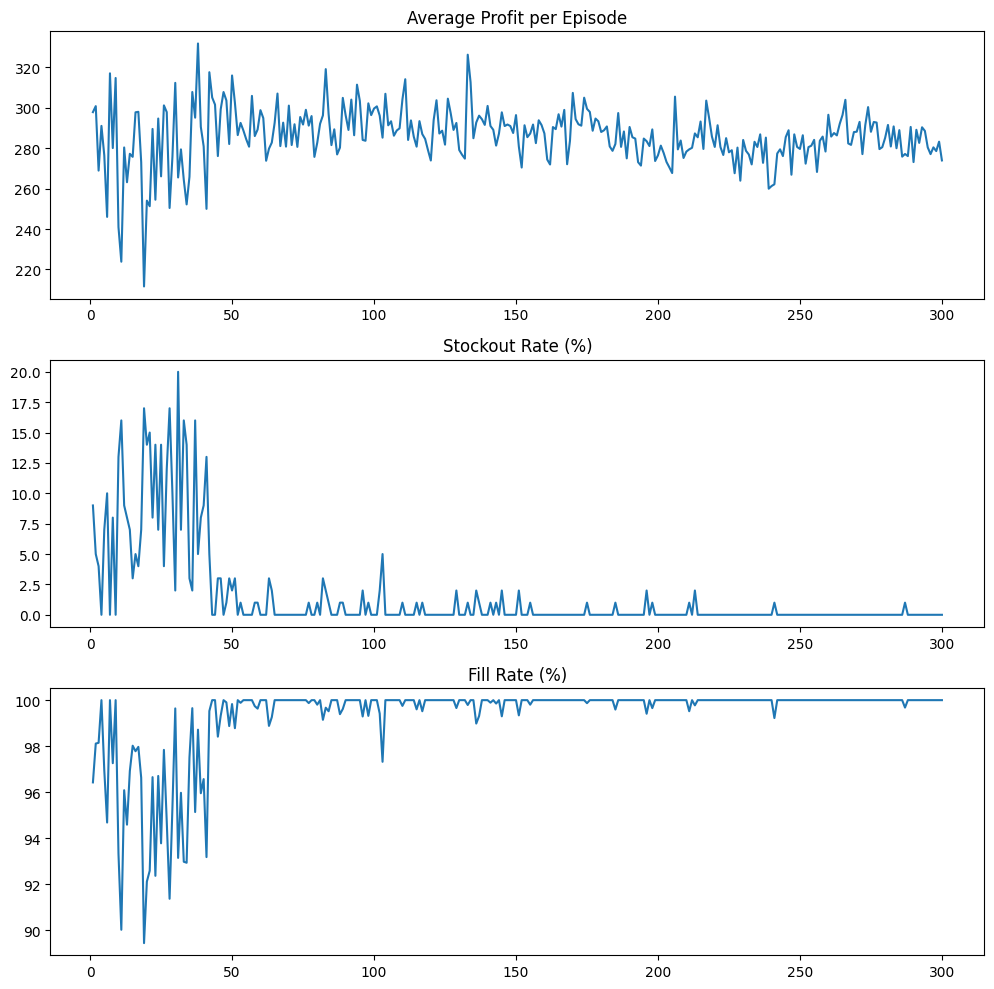

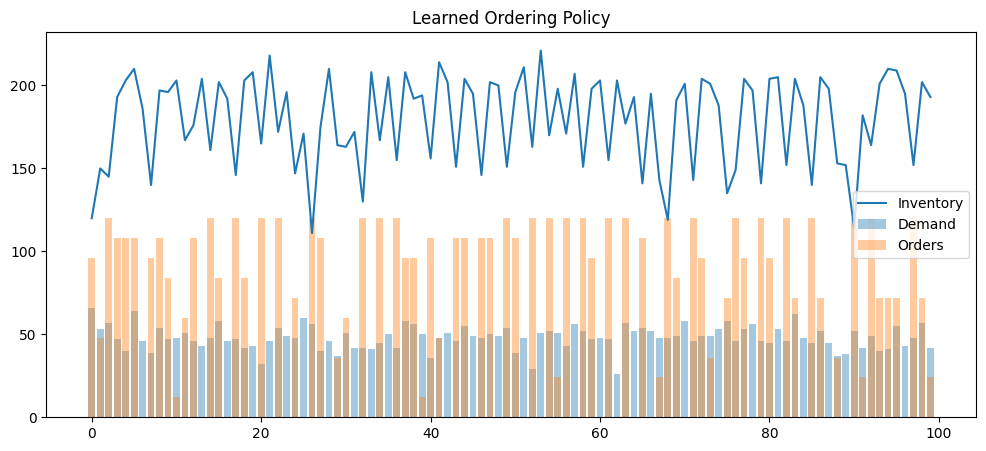


========== FINAL EVALUATION (NO EXPLORATION) ==========
Average Profit: 286.85
Stockout Rate: 0.00%
Fill Rate: 100.00%



In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt


# =========================================================
# CONFIGURATION
# =========================================================

CONFIG = {

    # Inventory system
    "max_order": 120,
    "max_inventory": 250,
    "initial_inventory": 120,

    # Pack constraint
    "pack_size": 12,

    # Costs
    "selling_price": 20,
    "ordering_cost": 12,
    "holding_cost": 0.8,
    "stockout_penalty": 15,

    # Demand distribution
    "demand_mean": 50,
    "demand_std": 10,

    # Forecast noise
    "forecast_noise_std": 5,

    # RL parameters
    "episodes": 300,
    "days_per_episode": 100,
    "batch_size": 64,
    "gamma": 0.99,
    "learning_rate": 5e-4,

    # Exploration
    "epsilon_start": 1.0,
    "epsilon_decay": 0.995,
    "epsilon_min": 0.05,

    # Neural network
    "hidden_units": 64
}

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)


# =========================================================
# ACTION SPACE
# =========================================================

def create_action_space(config):
    pack = config["pack_size"]
    max_order = config["max_order"]
    return list(range(0, max_order + 1, pack))

# =========================================================
# FINAL NUMERICAL RESULTS
# =========================================================

def evaluate_agent(env, agent, actions, episodes=10):

    agent.epsilon = 0  # no exploration (important)

    total_profit = 0
    total_stockout = 0
    total_fill = 0

    for _ in range(episodes):

        state = env.reset()

        for _ in range(CONFIG["days_per_episode"]):

            action_idx = agent.select_action(state)
            action = actions[action_idx]

            next_state, reward, demand, inventory_avail, stockout, fill = env.step(action)

            state = next_state

            total_profit += reward
            total_stockout += stockout
            total_fill += fill

    avg_profit = total_profit / (episodes * CONFIG["days_per_episode"])
    stockout_rate = (total_stockout / (episodes * CONFIG["days_per_episode"])) * 100
    fill_rate = (total_fill / (episodes * CONFIG["days_per_episode"])) * 100

    print("\n========== FINAL EVALUATION (NO EXPLORATION) ==========")
    print(f"Average Profit: {avg_profit:.2f}")
    print(f"Stockout Rate: {stockout_rate:.2f}%")
    print(f"Fill Rate: {fill_rate:.2f}%")
    print("======================================================\n")




# =========================================================
# INVENTORY ENVIRONMENT
# =========================================================

class InventoryEnv:

    def __init__(self, config):

        self.config = config

        self.max_order = config["max_order"]
        self.max_inventory = config["max_inventory"]

        self.price = config["selling_price"]
        self.order_cost = config["ordering_cost"]
        self.holding_cost = config["holding_cost"]
        self.stockout_penalty = config["stockout_penalty"]

        self.reset()

    def reset(self):

        self.inventory = self.config["initial_inventory"]
        self.pipeline = 0

        _, forecast = self.sample_demand()

        return np.array([self.inventory, self.pipeline, forecast], dtype=np.float32)

    def sample_demand(self):
        
        lam = self.config["demand_mean"]
        demand = np.random.poisson(lam)

        noise_std = self.config["forecast_noise_std"]
        noise = np.random.normal(0, noise_std)

        forecast = max(0, demand + noise)

        return demand, forecast

    def step(self, order):

        order = max(0, min(order, self.max_order))
        available_space = max(0, self.max_inventory - (self.inventory + self.pipeline))
        order = min(order, available_space)

        demand, _ = self.sample_demand()

        inventory_available = self.inventory + self.pipeline

        sales = min(inventory_available, demand)
        lost_sales = max(0, demand - inventory_available)

        next_inventory = inventory_available - sales
        next_pipeline = order

        revenue = self.price * sales
        ordering_cost = self.order_cost * order
        holding_cost = self.holding_cost * next_inventory
        stockout_cost = self.stockout_penalty * lost_sales

        reward = revenue - ordering_cost - holding_cost - stockout_cost

        self.inventory = next_inventory
        self.pipeline = next_pipeline

        _, next_forecast = self.sample_demand()

        next_state = np.array(
            [self.inventory, self.pipeline, next_forecast],
            dtype=np.float32
        )

        stockout = 1 if lost_sales > 0 else 0
        fill_rate = sales / demand if demand > 0 else 1

        return next_state, reward, demand, inventory_available, stockout, fill_rate


# =========================================================
# Q NETWORK
# =========================================================

class QNetwork(nn.Module):

    def __init__(self, state_dim, action_dim, hidden_units):

        super(QNetwork, self).__init__()

        self.fc1 = nn.Linear(state_dim, hidden_units)
        self.fc2 = nn.Linear(hidden_units, hidden_units)
        self.fc3 = nn.Linear(hidden_units, action_dim)

    def forward(self, x):

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))

        return self.fc3(x)


# =========================================================
# DQN AGENT
# =========================================================

class DQNAgent:

    def __init__(self, state_dim, action_dim, config):

        self.gamma = config["gamma"]

        self.epsilon = config["epsilon_start"]
        self.epsilon_decay = config["epsilon_decay"]
        self.epsilon_min = config["epsilon_min"]

        hidden = config["hidden_units"]

        self.q_network = QNetwork(state_dim, action_dim, hidden)
        self.target_network = QNetwork(state_dim, action_dim, hidden)

        self.target_network.load_state_dict(self.q_network.state_dict())

        self.optimizer = optim.Adam(
            self.q_network.parameters(),
            lr=config["learning_rate"]
        )

        self.loss_fn = nn.SmoothL1Loss()

        self.replay_buffer = deque(maxlen=50000)

        self.batch_size = config["batch_size"]
        self.action_dim = action_dim

    def select_action(self, state):

        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_dim)

        state_tensor = torch.FloatTensor(state).unsqueeze(0)

        with torch.no_grad():
            q_values = self.q_network(state_tensor)

        return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state):

        self.replay_buffer.append((state, action, reward, next_state))

    def train(self):

        if len(self.replay_buffer) < self.batch_size:
            return
    
        batch = random.sample(self.replay_buffer, self.batch_size)
    
        states, actions, rewards, next_states = zip(*batch)
    
        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states))
    
        # Current Q values
        current_q = self.q_network(states).gather(1, actions)
    
        with torch.no_grad():
    
            # 🔥 DOUBLE DQN CHANGE
    
            # Step 1: use MAIN network to select best action
            next_actions = self.q_network(next_states).argmax(1).unsqueeze(1)
    
            # Step 2: use TARGET network to evaluate that action
            next_q = self.target_network(next_states).gather(1, next_actions)
    
            target_q = rewards + self.gamma * next_q
    
        loss = self.loss_fn(current_q, target_q)
    
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


    def update_target_network(self):

        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# =========================================================
# VISUALIZATION
# =========================================================

def plot_training_metrics(episodes, profits, stockouts, fill_rates):

    fig, axs = plt.subplots(3, 1, figsize=(10, 10))

    axs[0].plot(episodes, profits)
    axs[0].set_title("Average Profit per Episode")

    axs[1].plot(episodes, stockouts)
    axs[1].set_title("Stockout Rate (%)")

    axs[2].plot(episodes, fill_rates)
    axs[2].set_title("Fill Rate (%)")

    plt.tight_layout()
    plt.show()


def plot_policy(days, inventory, orders, demand):

    plt.figure(figsize=(12, 5))

    plt.plot(days, inventory, label="Inventory")
    plt.bar(days, demand, alpha=0.4, label="Demand")
    plt.bar(days, orders, alpha=0.4, label="Orders")

    plt.legend()
    plt.title("Learned Ordering Policy")

    plt.show()


# =========================================================
# TRAINING LOOP
# =========================================================

def train():

    env = InventoryEnv(CONFIG)

    actions = create_action_space(CONFIG)

    agent = DQNAgent(
        state_dim=3,
        action_dim=len(actions),
        config=CONFIG
    )

    profits = []
    stockouts = []
    fill_rates = []

    for episode in range(CONFIG["episodes"]):

        state = env.reset()

        total_reward = 0
        total_stockout = 0
        total_fill = 0

        days = []
        inventory_history = []
        order_history = []
        demand_history = []

        for day in range(CONFIG["days_per_episode"]):

            action_idx = agent.select_action(state)
            action = actions[action_idx]

            next_state, reward, demand, inventory_avail, stockout, fill = env.step(action)

            agent.store_transition(state, action_idx, reward, next_state)

            agent.train()

            state = next_state

            total_reward += reward
            total_stockout += stockout
            total_fill += fill

            if episode == CONFIG["episodes"] - 1:

                days.append(day)
                inventory_history.append(inventory_avail)
                order_history.append(action)
                demand_history.append(demand)

        if episode % 10 == 0:
            agent.update_target_network()

        agent.decay_epsilon()

        profits.append(total_reward / CONFIG["days_per_episode"])
        stockouts.append((total_stockout / CONFIG["days_per_episode"]) * 100)
        fill_rates.append((total_fill / CONFIG["days_per_episode"]) * 100)

        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1}/{CONFIG['episodes']} | Profit {profits[-1]:.2f}")

    episodes = range(1, CONFIG["episodes"] + 1)

    plot_training_metrics(episodes, profits, stockouts, fill_rates)

    plot_policy(days, inventory_history, order_history, demand_history)
    evaluate_agent(env, agent, actions)


# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":
    train()
#code3

## 🎯 Actor-Critic Method for Inventory Optimization

This implementation replaces DQN with an Actor-Critic approach.  
The actor learns a policy (what action to take), while the critic evaluates how good the action is.  
This allows smoother learning and can handle more complex decision-making scenarios.

Episode 50 | Profit -702.80
Episode 100 | Profit 328.41
Episode 150 | Profit 337.39
Episode 200 | Profit 306.38
Episode 250 | Profit 351.31
Episode 300 | Profit 356.30

========== FINAL EVALUATION ==========
Average Profit: 349.31
Stockout Rate: 10.40%
Fill Rate: 98.64%



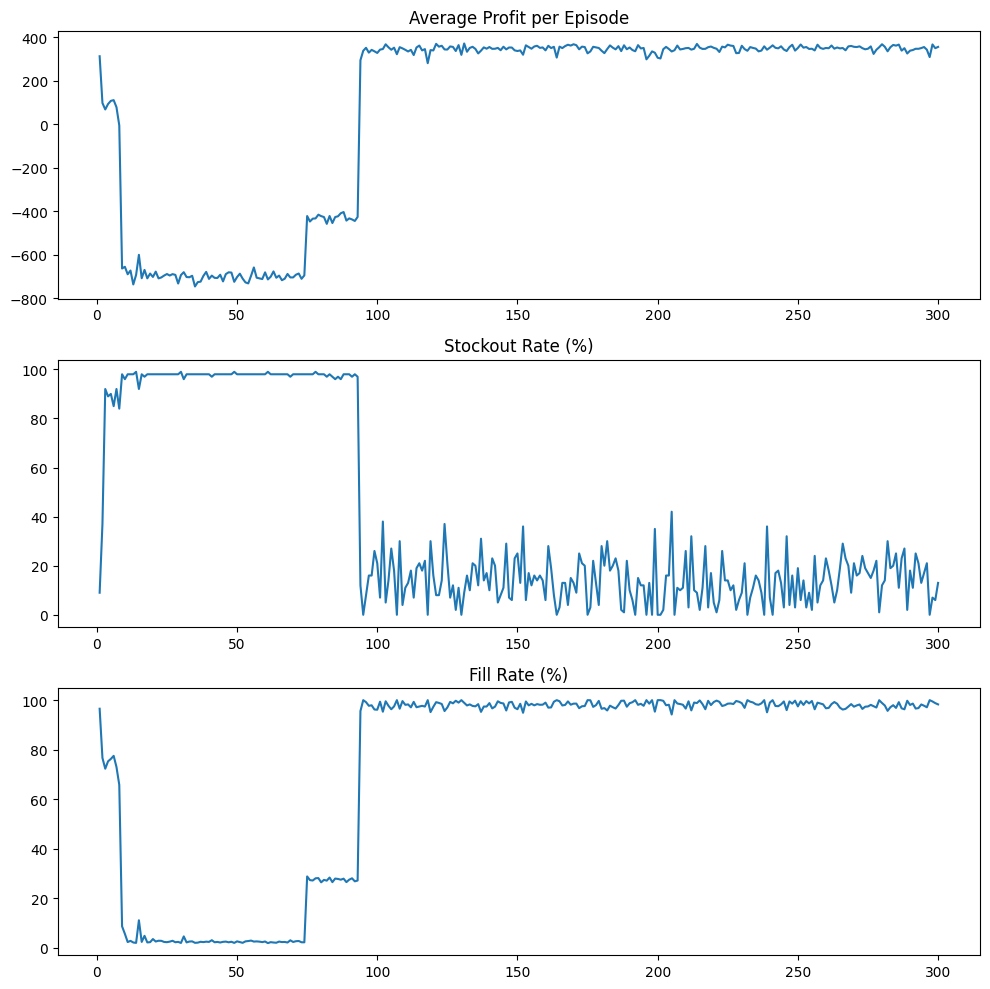

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURATION (UNCHANGED)
# =========================================================

CONFIG = {
    "max_order": 120,
    "max_inventory": 250,
    "initial_inventory": 120,
    "pack_size": 12,

    "selling_price": 20,
    "ordering_cost": 12,
    "holding_cost": 0.8,
    "stockout_penalty": 15,

    "demand_mean": 50,
    "demand_std": 10,
    "forecast_noise_std": 5,

    "episodes": 300,
    "days_per_episode": 100,
    "gamma": 0.99,
    "learning_rate": 5e-4,
    "hidden_units": 64
}

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# =========================================================
# ACTION SPACE (UNCHANGED)
# =========================================================

def create_action_space(config):
    return list(range(0, config["max_order"] + 1, config["pack_size"]))

# =========================================================
# ENVIRONMENT (UNCHANGED)
# =========================================================

class InventoryEnv:

    def __init__(self, config):
        self.config = config
        self.max_order = config["max_order"]
        self.max_inventory = config["max_inventory"]

        self.price = config["selling_price"]
        self.order_cost = config["ordering_cost"]
        self.holding_cost = config["holding_cost"]
        self.stockout_penalty = config["stockout_penalty"]

        self.reset()

    def reset(self):
        self.inventory = self.config["initial_inventory"]
        self.pipeline = 0
        _, forecast = self.sample_demand()
        return np.array([self.inventory, self.pipeline, forecast], dtype=np.float32)

    def sample_demand(self):
        demand = max(0, int(np.random.normal(self.config["demand_mean"], self.config["demand_std"])))
        noise = np.random.normal(0, self.config["forecast_noise_std"])
        forecast = max(0, demand + noise)
        return demand, forecast

    def step(self, order):
        order = max(0, min(order, self.max_order))
        available_space = max(0, self.max_inventory - (self.inventory + self.pipeline))
        order = min(order, available_space)

        demand, _ = self.sample_demand()

        inventory_available = self.inventory + self.pipeline

        sales = min(inventory_available, demand)
        lost_sales = max(0, demand - inventory_available)

        next_inventory = inventory_available - sales
        next_pipeline = order

        revenue = self.price * sales
        reward = revenue - self.order_cost * order - self.holding_cost * next_inventory - self.stockout_penalty * lost_sales

        self.inventory = next_inventory
        self.pipeline = next_pipeline

        _, next_forecast = self.sample_demand()

        next_state = np.array([self.inventory, self.pipeline, next_forecast], dtype=np.float32)

        stockout = 1 if lost_sales > 0 else 0
        fill_rate = sales / demand if demand > 0 else 1

        return next_state, reward, demand, inventory_available, stockout, fill_rate

# =========================================================
# ACTOR-CRITIC NETWORK
# =========================================================

class ActorCritic(nn.Module):

    def __init__(self, state_dim, action_dim, hidden_units):
        super().__init__()

        self.fc1 = nn.Linear(state_dim, hidden_units)

        self.actor = nn.Linear(hidden_units, action_dim)
        self.critic = nn.Linear(hidden_units, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        logits = self.actor(x)
        value = self.critic(x)
        return logits, value

# =========================================================
# AGENT
# =========================================================

class ACAgent:

    def __init__(self, state_dim, action_dim, config):

        self.gamma = config["gamma"]

        self.model = ActorCritic(state_dim, action_dim, config["hidden_units"])
        self.optimizer = optim.Adam(self.model.parameters(), lr=config["learning_rate"])

    def select_action(self, state):

        state = torch.FloatTensor(state).unsqueeze(0)

        logits, value = self.model(state)

        probs = torch.softmax(logits, dim=1)
        dist = torch.distributions.Categorical(probs)

        action = dist.sample()

        return action.item(), dist.log_prob(action), value

    def train(self, state, log_prob, value, reward, next_state):

        state = torch.FloatTensor(state).unsqueeze(0)
        next_state = torch.FloatTensor(next_state).unsqueeze(0)

        _, next_value = self.model(next_state)

        target = reward + self.gamma * next_value
        advantage = target - value

        actor_loss = -log_prob * advantage.detach()
        critic_loss = advantage.pow(2)

        loss = actor_loss + critic_loss

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

# =========================================================
# EVALUATION
# =========================================================

def evaluate_agent(env, agent, actions, episodes=10):

    total_profit, total_stockout, total_fill = 0, 0, 0

    for _ in range(episodes):
        state = env.reset()

        for _ in range(CONFIG["days_per_episode"]):
            action_idx, _, _ = agent.select_action(state)
            action = actions[action_idx]

            state, reward, _, _, stockout, fill = env.step(action)

            total_profit += reward
            total_stockout += stockout
            total_fill += fill

    print("\n========== FINAL EVALUATION ==========")
    print(f"Average Profit: {total_profit/(episodes*CONFIG['days_per_episode']):.2f}")
    print(f"Stockout Rate: {(total_stockout/(episodes*CONFIG['days_per_episode']))*100:.2f}%")
    print(f"Fill Rate: {(total_fill/(episodes*CONFIG['days_per_episode']))*100:.2f}%")
    print("======================================\n")

# =========================================================
# TRAINING
# =========================================================

def train():

    env = InventoryEnv(CONFIG)
    actions = create_action_space(CONFIG)

    agent = ACAgent(3, len(actions), CONFIG)

    profits, stockouts, fill_rates = [], [], []

    for episode in range(CONFIG["episodes"]):

        state = env.reset()

        total_reward = total_stockout = total_fill = 0

        for _ in range(CONFIG["days_per_episode"]):

            action_idx, log_prob, value = agent.select_action(state)
            action = actions[action_idx]

            next_state, reward, _, _, stockout, fill = env.step(action)

            agent.train(state, log_prob, value, reward, next_state)

            state = next_state

            total_reward += reward
            total_stockout += stockout
            total_fill += fill

        profits.append(total_reward / CONFIG["days_per_episode"])
        stockouts.append((total_stockout / CONFIG["days_per_episode"]) * 100)
        fill_rates.append((total_fill / CONFIG["days_per_episode"]) * 100)

        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1} | Profit {profits[-1]:.2f}")

    evaluate_agent(env, agent, actions)
    episodes_range = range(1, CONFIG["episodes"] + 1)
    plot_training_metrics(episodes_range, profits, stockouts, fill_rates)

# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":
    train()
#code4

## 🌍 Advanced Inventory Environment (Seasonality + Lead Time)

This version introduces real-world complexity like seasonal demand patterns and variable lead times.  
Orders now arrive after random delays, making the problem more challenging.  
The agent must learn to plan ahead under uncertainty for better long-term performance.

Episode 50
Episode 100
Episode 150
Episode 200
Episode 250
Episode 300


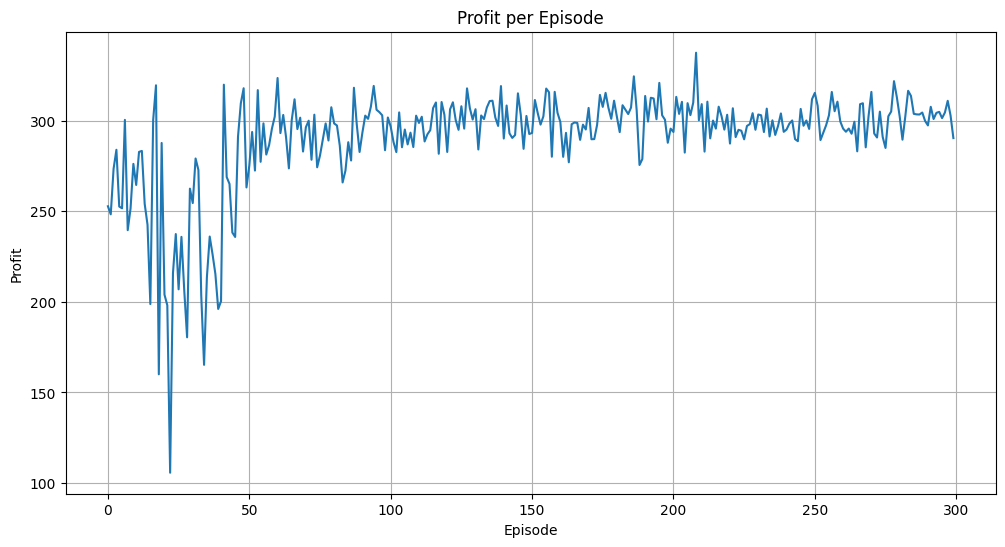

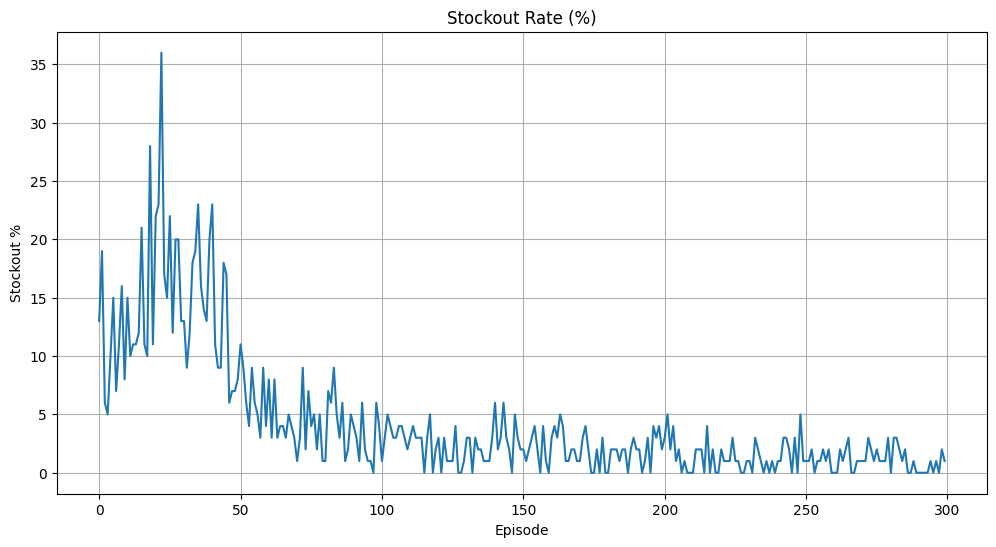

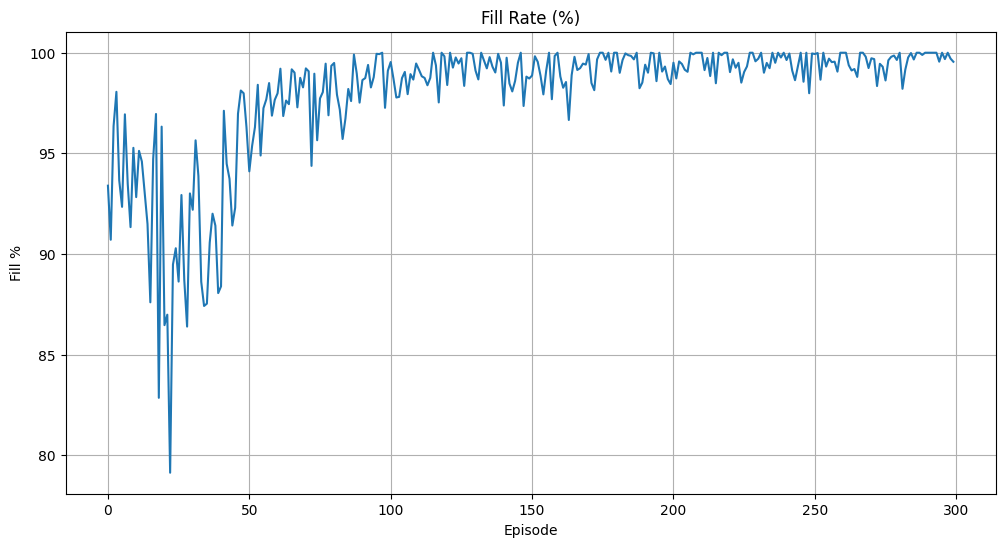

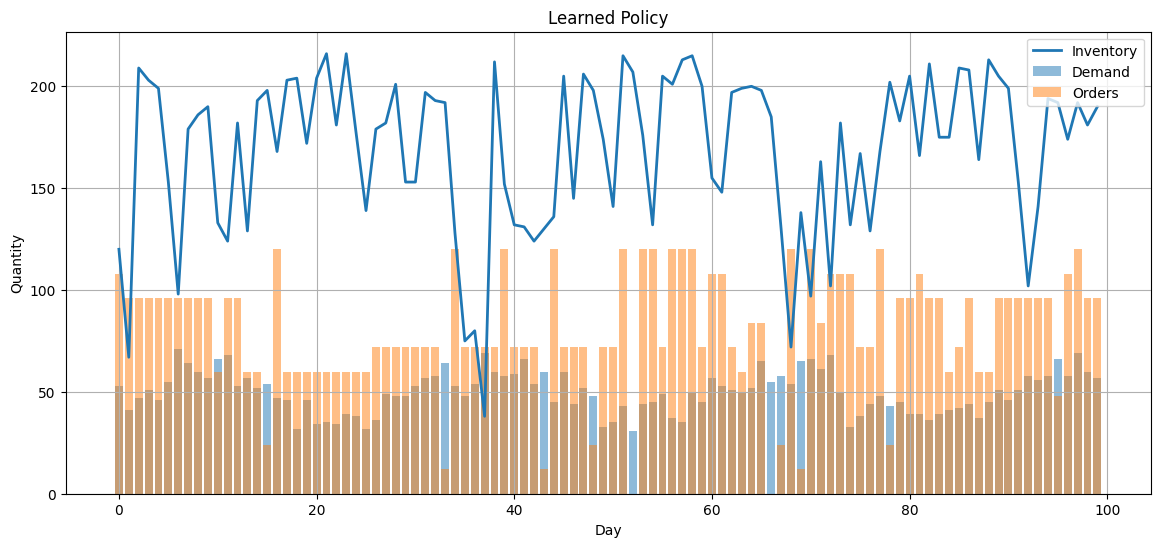


========== FINAL EVALUATION ==========
Average Profit: 298.82
Stockout Rate: 0.50%
Fill Rate: 99.86%



In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURATION
# =========================================================
CONFIG = {
    "max_order": 120,
    "max_inventory": 250,
    "initial_inventory": 120,
    "pack_size": 12,
    "selling_price": 20,
    "ordering_cost": 12,
    "holding_cost": 0.8,
    "stockout_penalty": 15,
    "demand_mean": 50,
    "demand_std": 10,
    "forecast_noise_std": 5,
    "lead_time_probs": {1: 0.6, 2: 0.25, 3: 0.1, 4: 0.05},
    "episodes": 300,
    "days_per_episode": 100,
    "batch_size": 64,
    "gamma": 0.99,
    "learning_rate": 5e-4,
    "epsilon_start": 1.0,
    "epsilon_decay": 0.995,
    "epsilon_min": 0.05,
    "hidden_units": 64
}

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# =========================================================
# ACTION SPACE
# =========================================================

def create_action_space(config):
    return list(range(0, config["max_order"] + 1, config["pack_size"]))

# =========================================================
# ENVIRONMENT
# =========================================================

class InventoryEnv:
    def __init__(self, config):
        self.config = config
        self.max_order = config["max_order"]
        self.max_inventory = config["max_inventory"]
        self.price = config["selling_price"]
        self.order_cost = config["ordering_cost"]
        self.holding_cost = config["holding_cost"]
        self.stockout_penalty = config["stockout_penalty"]
        self.reset()

    def reset(self):
        self.inventory = self.config["initial_inventory"]
        self.pipeline = []
        _, forecast = self.sample_demand(0)
        return np.array([self.inventory, 0, forecast], dtype=np.float32)

    def sample_demand(self, day):
        base = self.config["demand_mean"]
        seasonal = 10 * np.sin(2 * np.pi * day / 30)
        demand = np.random.poisson(max(0, base + seasonal))
        noise = np.random.normal(0, self.config["forecast_noise_std"])
        forecast = max(0, demand + noise)
        return demand, forecast

    def sample_lead_time(self):
        times = list(self.config["lead_time_probs"].keys())
        probs = list(self.config["lead_time_probs"].values())
        return np.random.choice(times, p=probs)

    def step(self, order, day):
        order = max(0, min(order, self.max_order))

        # receive arrivals
        arrived = 0
        new_pipeline = []
        for qty, days in self.pipeline:
            if days == 1:
                arrived += qty
            else:
                new_pipeline.append((qty, days - 1))

        self.pipeline = new_pipeline
        self.inventory += arrived

        pipeline_total = sum(q for q, _ in self.pipeline)
        available_space = max(0, self.max_inventory - (self.inventory + pipeline_total))
        order = min(order, available_space)

        lead_time = self.sample_lead_time()
        self.pipeline.append((order, lead_time))

        demand, _ = self.sample_demand(day)

        inventory_available = self.inventory
        sales = min(inventory_available, demand)
        lost_sales = max(0, demand - inventory_available)

        next_inventory = inventory_available - sales

        revenue = self.price * sales
        ordering_cost = self.order_cost * order
        holding_cost = self.holding_cost * next_inventory
        stockout_cost = self.stockout_penalty * lost_sales

        reward = revenue - ordering_cost - holding_cost - stockout_cost

        self.inventory = next_inventory

        _, next_forecast = self.sample_demand(day)
        pipeline_total = sum(q for q, _ in self.pipeline)

        next_state = np.array([self.inventory, pipeline_total, next_forecast], dtype=np.float32)

        stockout = 1 if lost_sales > 0 else 0
        fill_rate = sales / demand if demand > 0 else 1

        return next_state, reward, demand, inventory_available, stockout, fill_rate

# =========================================================
# NETWORK
# =========================================================

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_units):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_units)
        self.fc2 = nn.Linear(hidden_units, hidden_units)
        self.fc3 = nn.Linear(hidden_units, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# =========================================================
# AGENT
# =========================================================

class DQNAgent:
    def __init__(self, state_dim, action_dim, config):
        self.gamma = config["gamma"]
        self.epsilon = config["epsilon_start"]
        self.epsilon_decay = config["epsilon_decay"]
        self.epsilon_min = config["epsilon_min"]

        self.q_network = QNetwork(state_dim, action_dim, config["hidden_units"])
        self.target_network = QNetwork(state_dim, action_dim, config["hidden_units"])
        self.target_network.load_state_dict(self.q_network.state_dict())

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=config["learning_rate"])
        self.loss_fn = nn.SmoothL1Loss()

        self.replay_buffer = deque(maxlen=50000)
        self.batch_size = config["batch_size"]
        self.action_dim = action_dim

    def select_action(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_dim)
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state):
        self.replay_buffer.append((state, action, reward, next_state))

    def train(self):
        if len(self.replay_buffer) < self.batch_size:
            return
        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, rewards, next_states = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states))

        current_q = self.q_network(states).gather(1, actions)

        with torch.no_grad():
            next_q = self.target_network(next_states).max(1)[0].unsqueeze(1)
            target_q = rewards + self.gamma * next_q

        loss = self.loss_fn(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# =========================================================
# PLOTS
# =========================================================

def plot_training(episodes, profits, stockouts, fills):
    plt.figure(figsize=(12,6))
    plt.plot(episodes, profits)
    plt.title("Profit per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Profit")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12,6))
    plt.plot(episodes, stockouts)
    plt.title("Stockout Rate (%)")
    plt.xlabel("Episode")
    plt.ylabel("Stockout %")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12,6))
    plt.plot(episodes, fills)
    plt.title("Fill Rate (%)")
    plt.xlabel("Episode")
    plt.ylabel("Fill %")
    plt.grid(True)
    plt.show()

def plot_policy(days, inventory, orders, demand):
    plt.figure(figsize=(14,6))
    plt.plot(days, inventory, label="Inventory", linewidth=2)
    plt.bar(days, demand, alpha=0.5, label="Demand")
    plt.bar(days, orders, alpha=0.5, label="Orders")
    plt.legend()
    plt.title("Learned Policy")
    plt.xlabel("Day")
    plt.ylabel("Quantity")
    plt.grid(True)
    plt.show()

# =========================================================
# EVALUATION
# =========================================================

def evaluate_agent(env, agent, actions, episodes=10):
    agent.epsilon = 0
    total_profit = total_stockout = total_fill = 0

    for _ in range(episodes):
        state = env.reset()
        for day in range(CONFIG["days_per_episode"]):
            action_idx = agent.select_action(state)
            action = actions[action_idx]

            state, reward, _, _, stockout, fill = env.step(action, day)

            total_profit += reward
            total_stockout += stockout
            total_fill += fill

    print("\n========== FINAL EVALUATION ==========")
    print(f"Average Profit: {total_profit/(episodes*CONFIG['days_per_episode']):.2f}")
    print(f"Stockout Rate: {(total_stockout/(episodes*CONFIG['days_per_episode']))*100:.2f}%")
    print(f"Fill Rate: {(total_fill/(episodes*CONFIG['days_per_episode']))*100:.2f}%")
    print("======================================\n")

# =========================================================
# TRAIN
# =========================================================

def train():
    env = InventoryEnv(CONFIG)
    actions = create_action_space(CONFIG)
    agent = DQNAgent(3, len(actions), CONFIG)

    profits, stockouts, fills = [], [], []

    for episode in range(CONFIG["episodes"]):
        state = env.reset()

        total_reward = total_stockout = total_fill = 0

        days, inv_hist, order_hist, demand_hist = [], [], [], []

        for day in range(CONFIG["days_per_episode"]):
            action_idx = agent.select_action(state)
            action = actions[action_idx]

            next_state, reward, demand, inv, stockout, fill = env.step(action, day)

            agent.store_transition(state, action_idx, reward, next_state)
            agent.train()

            state = next_state

            total_reward += reward
            total_stockout += stockout
            total_fill += fill

            if episode == CONFIG["episodes"] - 1:
                days.append(day)
                inv_hist.append(inv)
                order_hist.append(action)
                demand_hist.append(demand)

        if episode % 10 == 0:
            agent.update_target_network()

        agent.decay_epsilon()

        profits.append(total_reward / CONFIG["days_per_episode"])
        stockouts.append((total_stockout / CONFIG["days_per_episode"]) * 100)
        fills.append((total_fill / CONFIG["days_per_episode"]) * 100)

        if (episode + 1) % 50 == 0:
            print(f"Episode {episode+1}")

    plot_training(range(CONFIG["episodes"]), profits, stockouts, fills)
    plot_policy(days, inv_hist, order_hist, demand_hist)
    evaluate_agent(env, agent, actions)

if __name__ == "__main__":
    train()

#LastCode
